# Tutorial: End-to-End Haydn Training with Configs, Splits, Evaluation, and Deployable Artifacts

This notebook shows a practical workflow:

1. Create a YAML experiment config
2. Build train/val/test CSV splits with `scripts/datasplit.py`
3. Train with Lightning using custom checkpointing
4. Evaluate with MSE and $R^2$ (plus extra regression diagnostics)
5. Visualize diagonal and off-diagonal channels with robust controls
6. Export deployable `.pt` artifacts with normalization + TorchScript

In [46]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger

from closure import ClosureDataModule, ClosureLitModule, MLP
import closure.evaluation as ev
from closure.visualization import plot_pred_targets

## 1) Paths and working directories

Set data/model paths once and reuse them in every section. This keeps experiments reproducible and portable.

Adjust these paths if you run on a different machine.

In [47]:
project_root = Path('/volume1/scratch/georgem/closure')
data_root = Path('/volume1/scratch/share_dir/ecsim')
work_dir = project_root / 'models' / 'dev' / 'dev16'

split_dir = work_dir / 'splits'
config_dir = work_dir / 'configs'
artifact_dir = work_dir / 'artifacts'

for p in [work_dir, split_dir, config_dir, artifact_dir]:
    p.mkdir(parents=True, exist_ok=True)

print('work_dir   :', work_dir)
print('split_dir  :', split_dir)
print('config_dir :', config_dir)
print('artifact_dir:', artifact_dir)

work_dir   : /volume1/scratch/georgem/closure/models/dev/dev16
split_dir  : /volume1/scratch/georgem/closure/models/dev/dev16/splits
config_dir : /volume1/scratch/georgem/closure/models/dev/dev16/configs
artifact_dir: /volume1/scratch/georgem/closure/models/dev/dev16/artifacts


## 2) Build a YAML experiment config

We save one config file that captures data, model, optimization, and trainer settings.

In [80]:
import yaml

run_config = {
    'name': 'haydn_mlp_baseline',
    'data': {
        'data_folder': str(data_root),
        'norm_folder': str(work_dir),
        'flatten': True,
        'scaler_features': True,
        'scaler_targets': True,
        'prescaler_features': ['arcsinh','arcsinh','arcsinh','arcsinh','arcsinh','arcsinh',None,None,None,None],
        'prescaler_targets': ['log','log','log'],
        'read_features_targets_kwargs': {
            'fields_to_read': {
                'B': True,
                'E': True,
                'B_ext': False,
                'E_ext': False,
                'divB': False,
                'rho': True,
                'N': False,
                'Qrem': False,
                'J': True,
                'P': True,
                'PI': True,
                'divP': False,
                'Ohmres': False,
                'Heat_flux': False,
                'gyro_radius': False,
                'EF': False,
            },
            'request_features': [
                'rho_e',
                'Bx','By','Bz',
                'Jx_e','Jy_e','Jz_e',
                'Vx_e','Vy_e','Vz_e',
            ],
            'request_targets': ['Pxx_e','Pyy_e','Pzz_e'],
            'choose_species': ['e', None],
            'choose_x': [0, 256],
            'choose_y': [0, 256],
            'verbose': False,
        },
    },
    'split': {
        'root_folder': str(data_root),
        'train_folders': ['peppe/T2D13_filter1', 'peppe/T2D15_filter1'],
        'val_folders': ['peppe/T2D13_filter1'],
        'test_folders': ['peppe/T2D15_filter1'],
        'pattern': 'T2D-Fields_*',
        'train_range': [0, 12000],
        'val_range': [12000, 16000],
        'test_range': [16000, 22000],
    },
    'model': {
        'feature_dims': [10, 60, 80, 50, 40, 3],
        'activations': ['Tanh', 'Tanh', 'Tanh', 'Tanh', None],
    },
    'optimizer': {
        'criterion': 'MSELoss',
        'metrics': ['L1Loss'],
        'optimizer': 'Adam',
        'lr': 5e-4,
        'weight_decay': 0.0,
        'scheduler': 'ReduceLROnPlateau',
        'scheduler_kwargs': {'mode': 'min', 'factor': 0.6, 'patience': 4, 'threshold': 1e-3},
    },
    'trainer': {
        'batch_size': 1024,
        'num_workers': 8,
        'max_epochs': 40,
        'accelerator': 'gpu',
        'devices': 1,
        'precision': '16-mixed',
        'gradient_clip_val': 1.0,
        'log_every_n_steps': 25,
    },
}

config_path = config_dir / 'haydn_mlp.yaml'
with open(config_path, 'w') as f:
    yaml.safe_dump(run_config, f, sort_keys=False)

print('Wrote:', config_path)

Wrote: /volume1/scratch/georgem/closure/models/dev/dev16/configs/haydn_mlp.yaml


Inspecting the saved YAML confirms exactly what will be run.

In [81]:
print(config_path.read_text()[:1600])

name: haydn_mlp_baseline
data:
  data_folder: /volume1/scratch/share_dir/ecsim
  norm_folder: /volume1/scratch/georgem/closure/models/dev/dev16
  flatten: true
  scaler_features: true
  scaler_targets: true
  prescaler_features:
  - arcsinh
  - arcsinh
  - arcsinh
  - arcsinh
  - arcsinh
  - arcsinh
  - null
  - null
  - null
  - null
  prescaler_targets:
  - log
  - log
  - log
  read_features_targets_kwargs:
    fields_to_read:
      B: true
      E: true
      B_ext: false
      E_ext: false
      divB: false
      rho: true
      N: false
      Qrem: false
      J: true
      P: true
      PI: true
      divP: false
      Ohmres: false
      Heat_flux: false
      gyro_radius: false
      EF: false
    request_features:
    - rho_e
    - Bx
    - By
    - Bz
    - Jx_e
    - Jy_e
    - Jz_e
    - Vx_e
    - Vy_e
    - Vz_e
    request_targets:
    - Pxx_e
    - Pyy_e
    - Pzz_e
    choose_species:
    - e
    - null
    choose_x:
    - 0
    - 256
    choose_y:
    - 0
    - 256
 

## 3) Create data split CSV files with scripts/datasplit.py

The helper below reuses the script logic directly in Python so the notebook remains self-contained.

In [82]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    'datasplit', project_root / 'scripts' / 'datasplit.py'
)
datasplit = importlib.util.module_from_spec(spec)
spec.loader.exec_module(datasplit)
create_files_csv = datasplit.create_files_csv

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

split_cfg = cfg['split']

train_csv = split_dir / 'train.csv'
val_csv = split_dir / 'val.csv'
test_csv = split_dir / 'test.csv'

create_files_csv(
    split_cfg['train_folders'],
    str(train_csv),
    pattern=split_cfg['pattern'],
    root_folder=split_cfg['root_folder'],
    min_number=split_cfg['train_range'][0],
    max_number=split_cfg['train_range'][1],
)
create_files_csv(
    split_cfg['val_folders'],
    str(val_csv),
    pattern=split_cfg['pattern'],
    root_folder=split_cfg['root_folder'],
    min_number=split_cfg['val_range'][0],
    max_number=split_cfg['val_range'][1],
)
create_files_csv(
    split_cfg['test_folders'],
    str(test_csv),
    pattern=split_cfg['pattern'],
    root_folder=split_cfg['root_folder'],
    min_number=split_cfg['test_range'][0],
    max_number=split_cfg['test_range'][1],
)

print('Split files:')
print(train_csv)
print(val_csv)
print(test_csv)

Created /volume1/scratch/georgem/closure/models/dev/dev16/splits/train.csv with 52 files from 2 folders
Found 95 total files, filtered out 43 files with numbers < 0 and numbers > 12000
Created /volume1/scratch/georgem/closure/models/dev/dev16/splits/val.csv with 9 files from 1 folders
Found 51 total files, filtered out 42 files with numbers < 12000 and numbers > 16000
Created /volume1/scratch/georgem/closure/models/dev/dev16/splits/test.csv with 11 files from 1 folders
Found 44 total files, filtered out 33 files with numbers < 16000 and numbers > 22000
Split files:
/volume1/scratch/georgem/closure/models/dev/dev16/splits/train.csv
/volume1/scratch/georgem/closure/models/dev/dev16/splits/val.csv
/volume1/scratch/georgem/closure/models/dev/dev16/splits/test.csv


Quick sanity check of split sizes and first few entries.

In [51]:
for csv_path in [train_csv, val_csv, test_csv]:
    df = pd.read_csv(csv_path)
    print(f"{csv_path.name}: {len(df)} rows")
    display(df.head(3))

train.csv: 52 rows


,filenames
0,peppe/T2D13_filter1/T2D-Fields_000000.h5.pkl
1,peppe/T2D13_filter1/T2D-Fields_000001.h5.pkl
2,peppe/T2D13_filter1/T2D-Fields_000500.h5.pkl


val.csv: 9 rows


,filenames
0,peppe/T2D13_filter1/T2D-Fields_012000.h5.pkl
1,peppe/T2D13_filter1/T2D-Fields_012500.h5.pkl
2,peppe/T2D13_filter1/T2D-Fields_013000.h5.pkl


test.csv: 11 rows


,filenames
0,peppe/T2D15_filter1/T2D-Fields_016000.h5.pkl
1,peppe/T2D15_filter1/T2D-Fields_016500.h5.pkl
2,peppe/T2D15_filter1/T2D-Fields_017000.h5.pkl


## 4) Initialize DataModule, Model, and Lightning Trainer with custom checkpointing

We configure checkpoint naming and retention explicitly so run management is predictable.

In [83]:
data_cfg = cfg['data']
model_cfg = cfg['model']
opt_cfg = cfg['optimizer']
trainer_cfg = cfg['trainer']

datamodule = ClosureDataModule(
    data_folder=data_cfg['data_folder'],
    norm_folder=data_cfg['norm_folder'],
    train_samples_file=str(train_csv),
    val_samples_file=str(val_csv),
    test_samples_file=str(test_csv),
    batch_size=trainer_cfg['batch_size'],
    num_workers=trainer_cfg['num_workers'],
    flatten=data_cfg['flatten'],
    scaler_features=data_cfg['scaler_features'],
    scaler_targets=data_cfg['scaler_targets'],
    prescaler_features=data_cfg['prescaler_features'],
    prescaler_targets=data_cfg['prescaler_targets'],
    read_features_targets_kwargs=data_cfg['read_features_targets_kwargs'],
)

network = MLP(
    feature_dims=model_cfg['feature_dims'],
    activations=model_cfg['activations'],
)

scheduler_kwargs = dict(opt_cfg.get('scheduler_kwargs', {}))
scheduler_kwargs.pop('scheduler', None)

module = ClosureLitModule(
    network=network,
    criterion=opt_cfg['criterion'],
    metrics=opt_cfg.get('metrics'),
    optimizer=opt_cfg['optimizer'],
    lr=opt_cfg['lr'],
    weight_decay=opt_cfg.get('weight_decay', 0.0),
    scheduler=opt_cfg.get('scheduler'),
    scheduler_kwargs=scheduler_kwargs,
)

ckpt_callback = ModelCheckpoint(
    dirpath=work_dir / 'checkpoints',
    filename='epoch{epoch:03d}-valloss{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=3,
    save_last=True,
)

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=10,
)

logger = CSVLogger(save_dir=str(work_dir), name='lightning_logs')

trainer = L.Trainer(
    max_epochs=trainer_cfg['max_epochs'],
    accelerator=trainer_cfg['accelerator'],
    devices=trainer_cfg['devices'],
    precision=trainer_cfg['precision'],
    gradient_clip_val=trainer_cfg['gradient_clip_val'],
    log_every_n_steps=trainer_cfg['log_every_n_steps'],
    default_root_dir=str(work_dir),
    callbacks=[ckpt_callback, early_stop],
    logger=logger,
)

trainer

Using 16bit Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [84]:
datamodule.setup('fit')
print('train samples:', len(datamodule.train_dataset))
print('val samples  :', len(datamodule.val_dataset))
print('target channels:', datamodule.train_dataset.request_targets)

INFO:closure.datasets: This is train set
INFO:closure.datasets:Loading data split from: /volume1/scratch/georgem/closure/models/dev/dev16/splits/train.csv
INFO:closure.read_pic:About to transpose array with shape (52, 10, 256, 256)
INFO:closure.read_pic:About to transpose array with shape (52, 3, 256, 256)
INFO:closure.datasets:Data shape - Features: (3407872, 10), Targets: (3407872, 3)
INFO:closure.datasets:Applied arcsinh to features channel 0
INFO:closure.datasets:Applied arcsinh to features channel 1
INFO:closure.datasets:Applied arcsinh to features channel 2
INFO:closure.datasets:Applied arcsinh to features channel 3
INFO:closure.datasets:Applied arcsinh to features channel 4
INFO:closure.datasets:Applied arcsinh to features channel 5
INFO:closure.datasets:Loaded normalization parameters for features from /volume1/scratch/georgem/closure/models/dev/dev16/X.pkl
INFO:closure.datasets:Applying normalization to features
INFO:closure.datasets:Applied log to targets channel 0
INFO:closu

train samples: 3407872
val samples  : 589824
target channels: ['Pxx_e', 'Pyy_e', 'Pzz_e']


## 5) Train (optional in notebook)

Set `RUN_TRAIN = True` to train in this session. Keeping it `False` allows quick walkthrough without long runtime.

In [54]:
RUN_TRAIN = False
if RUN_TRAIN:
    trainer.fit(module, datamodule=datamodule)
    print('Best checkpoint:', ckpt_callback.best_model_path)
else:
    print('Skipped training. Set RUN_TRAIN=True to execute fit().')

Skipped training. Set RUN_TRAIN=True to execute fit().


### Monitor training curves from Lightning CSV logs

This works whether you trained now or are reusing an existing run in the same work directory.

In [55]:
version_dirs = sorted((work_dir / 'lightning_logs').glob('version_*'))
print('Found', len(version_dirs), 'logged versions')
print([v.name for v in version_dirs[-5:]])

Found 2 logged versions
['version_0', 'version_1']


In [ ]:
if not version_dirs:
    print('No logs available yet.')
else:
    metrics_path = version_dirs[-1] / 'metrics.csv'
    metrics = pd.read_csv(metrics_path)
    display(metrics.tail(10))

(tensor([ 1.6706e-08, -1.1176e-08,  2.0955e-09, -1.7462e-10, -6.9849e-10,
          1.6531e-08,  2.8231e-09, -5.1223e-09,  4.4238e-09,  3.6089e-09]),
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000]))

In [ ]:
if not version_dirs:
    print('No logs available yet.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    for vdir in version_dirs[-3:]:
        csv = vdir / 'metrics.csv'
        if not csv.exists():
            continue
        m = pd.read_csv(csv)
        if 'val_loss' in m.columns:
            val_df = m.dropna(subset=['val_loss'])
            ax.plot(val_df['epoch'], val_df['val_loss'], label=f"{vdir.name} val_loss")
        if 'train_loss' in m.columns:
            tr_df = m.dropna(subset=['train_loss'])
            ax.plot(tr_df['epoch'], tr_df['train_loss'], linestyle=':', label=f"{vdir.name} train_loss")
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title('Training/validation losses')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

(tensor([ 0.1214, -0.2076,  0.0554, -0.0732,  0.2455, -0.1087, -0.0684,  0.0879,
          0.1847, -0.3582]),
 tensor([0.8271, 1.1260, 0.8411, 1.0146, 0.8598, 0.8141, 1.2448, 0.9926, 0.9901,
         1.0612]))

### Optional: load best checkpoint for evaluation

If no checkpoint is available, we evaluate with the in-memory module.

In [ ]:
best_ckpt = ckpt_callback.best_model_path if ckpt_callback.best_model_path else None
if best_ckpt and Path(best_ckpt).exists():
    module_eval = ClosureLitModule.load_from_checkpoint(best_ckpt, network=network)
    print('Loaded checkpoint:', best_ckpt)
else:
    module_eval = module
    print('No checkpoint found, using current module state.')

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:closure.datasets: This is train set
INFO:closure.datasets:Loading data split from: /volume1/scratch/share_dir/brecht/sampling/turbulence/train.csv
INFO:closure.read_pic:About to transpose array with shape (16, 10, 256, 256)
INFO:closure.read_pic:About to transpose array with shape (16, 6, 256, 256)
INFO:closure.datasets:Data shape - Features: (1048576, 10), Targets: (1048576, 6)
INFO:closure.datasets:Loaded normalization parameters for features from /volume1/scratch/georgem/closure/models/dev/dev16//X.pkl
INFO:closure.datasets:Applying normalization to features
INFO:closure.datasets:Applied log to targets channel 0
INFO:closure.dataset

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ MLP     │ 11.9 K │ train │     0 │
│ 1 │ criterion │ MSELoss │      0 │ train │     0 │
└───┴───────────┴─────────┴────────┴───────┴───────┘

Trainable params: 11.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


In [ ]:
datamodule.setup('test')

ground_truth, prediction = ev.transform_targets(
    module_eval,
    datamodule.test_dataset,
    target_channels=datamodule.target_channels,
    rescale=False,
    renorm=False,
    verbose=False,
    reshape=False,
    test_features=datamodule.test_dataset.features,
)

print('prediction shape :', prediction.shape)
print('ground_truth shape:', ground_truth.shape)

lightning_logs	X.pkl  y.pkl


## 6) Evaluation metrics: MSE, MAE, RMSE, $R^2$, correlation

Use both the classic loss report and the new regression table for channel-wise diagnostics.

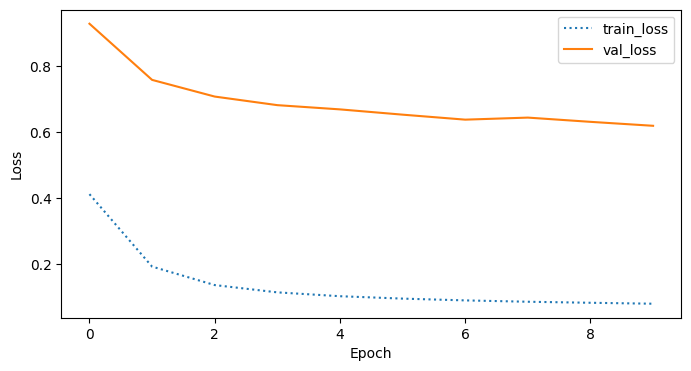

In [ ]:
mse_report = ev.evaluate_loss(
    datamodule.test_dataset,
    ground_truth,
    prediction,
    'MSELoss',
    target_channels=datamodule.target_channels,
    verbose=True,
)

r2_report = ev.evaluate_loss(
    datamodule.test_dataset,
    ground_truth,
    prediction,
    'r2',
    target_channels=datamodule.target_channels,
    verbose=True,
)

metrics_df = ev.evaluate_regression_metrics(
    datamodule.test_dataset,
    ground_truth,
    prediction,
    target_channels=datamodule.target_channels,
)

display(metrics_df.sort_values('r2', ascending=False))

Plot a compact comparison of channel-wise $R^2$ and normalized RMSE.

Lower normalized RMSE and higher $R^2$ indicate better channel quality.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics_sorted = metrics_df.set_index('channel').sort_index()
metrics_sorted['r2'].plot.bar(ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Channel-wise $R^2$')
axes[0].set_ylim(-0.2, 1.0)
axes[0].grid(axis='y', alpha=0.3)

metrics_sorted['nrmse'].plot.bar(ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title('Channel-wise normalized RMSE')
axes[1].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.set_xlabel('target channel')

plt.tight_layout()
plt.show()

## 7) Controlled visualization for diagonal vs off-diagonal components

The upgraded plotting helper supports robust scaling and signed-target handling.

In [ ]:
plot_pred_targets(
    datamodule.test_dataset,
    'Pxx_e',
    prediction,
    ground_truth,
    data_folder=data_cfg['data_folder'],
    read_features_targets_kwargs=data_cfg['read_features_targets_kwargs'],
    target_channels=datamodule.target_channels,
    output_dir=str(work_dir),
    plot_indices=[0, 1, 2],
    figsize=(12, 8),
    robust_quantile=0.995,
    error_mode='relative',
    signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'],
)

{'run': 'nosubsample',
 'load_data_kwargs': {'train_loader_kwargs': {'batch_size': 512,
   'subsample_rate': 1,
   'subsample_seed': 42,
   'seed': 42,
   'shuffle': True},
  'val_loader_kwargs': {'batch_size': 512,
   'subsample_rate': 1,
   'subsample_seed': 42,
   'shuffle': False}}}

Off-diagonal channels are signed, so diverging maps are used with symmetric limits around zero.

In [ ]:
target_to_plot = 'Pxz_e' if 'Pxz_e' in datamodule.test_dataset.request_targets else datamodule.test_dataset.request_targets[0]
plot_pred_targets(
    datamodule.test_dataset,
    target_to_plot,
    prediction,
    ground_truth,
    data_folder=data_cfg['data_folder'],
    read_features_targets_kwargs=data_cfg['read_features_targets_kwargs'],
    target_channels=datamodule.target_channels,
    output_dir=str(work_dir),
    plot_indices=[0, 1, 2],
    figsize=(12, 8),
    robust_quantile=0.995,
    error_mode='symmetric_percent',
    error_limit=0.5,
    signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'],
)
print('Plotted target:', target_to_plot)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:closure.datasets: This is train set
INFO:closure.datasets:Loading data split from: /volume1/scratch/share_dir/brecht/sampling/turbulence/train.csv
INFO:closure.read_pic:About to transpose array with shape (16, 10, 256, 256)
INFO:closure.read_pic:About to transpose array with shape (16, 6, 256, 256)
INFO:closure.datasets:Data shape - Features: (1048576, 10), Targets: (1048576, 6)
INFO:closure.datasets:L

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ MLP     │ 11.9 K │ train │     0 │
│ 1 │ criterion │ MSELoss │      0 │ train │     0 │
└───┴───────────┴─────────┴────────┴───────┴───────┘

Trainable params: 11.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


## 8) Compare multiple runs quickly from logger outputs

In [ ]:
log_dirs = [str(p) for p in sorted((work_dir / 'lightning_logs').glob('version_*'))[-5:]]
run_summary = ev.compare_runs(log_dirs=log_dirs, metric_key='val_loss')
run_summary = run_summary.sort_values('best_val_loss', na_position='last')
display(run_summary)

Top-level files:
lightning_logs	X.pkl  y.pkl

Detected Lightning runs:
  version_0
  version_1


In [ ]:
if run_summary.dropna(subset=['best_val_loss']).empty:
    print('No finite val_loss available yet.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_df = run_summary.dropna(subset=['best_val_loss']).copy()
    plot_df['run'] = [Path(x).name for x in plot_df['log_dir']]
    ax.bar(plot_df['run'], plot_df['best_val_loss'], color='teal', alpha=0.85)
    ax.set_ylabel('best val_loss')
    ax.set_xlabel('run')
    ax.set_title('Best validation loss across runs')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

work directory: /volume1/scratch/georgem/closure/models/dev/dev16/
number of Lightning runs: 2
latest runs: ['version_0', 'version_1']


## 9) Export a deployment bundle (.pt) that ships normalization with model weights

This bundle is convenient for downstream inference without separately tracking scaler files.

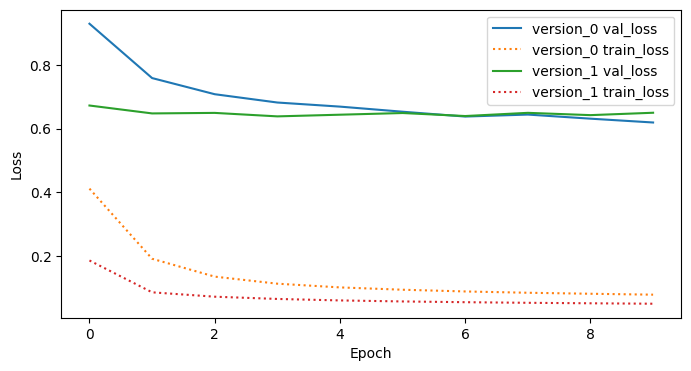

In [ ]:
bundle_path = artifact_dir / 'haydn_mlp_inference_bundle.pt'

ds = datamodule.test_dataset
artifact_bundle = {
    'state_dict': module_eval.network.state_dict(),
    'model_kwargs': {
        'feature_dims': model_cfg['feature_dims'],
        'activations': model_cfg['activations'],
    },
    'request_features': ds.request_features,
    'request_targets': ds.request_targets,
    'target_channels': datamodule.target_channels,
    'feature_channels': datamodule.feature_channels,
    'features_mean': np.asarray(ds.features_mean),
    'features_std': np.asarray(ds.features_std),
    'targets_mean': np.asarray(ds.targets_mean),
    'targets_std': np.asarray(ds.targets_std),
    'prescaler_features': [None if f is None else f.__name__ for f in ds.prescaler_features],
    'prescaler_targets': [None if f is None else f.__name__ for f in ds.prescaler_targets],
    'flatten': ds.flatten,
}

torch.save(artifact_bundle, bundle_path)
print('Saved bundle:', bundle_path)

Quick inspection of bundle metadata.

In [ ]:
loaded_bundle = torch.load(bundle_path, map_location='cpu')
print('bundle keys:', sorted(list(loaded_bundle.keys())))
print('n_features:', len(loaded_bundle['request_features']))
print('n_targets :', len(loaded_bundle['request_targets']))
print('prescaler_targets:', loaded_bundle['prescaler_targets'])

INFO:closure.datasets: This is test set
INFO:closure.datasets:Loading data split from: /volume1/scratch/share_dir/brecht/sampling/turbulence/test.csv
INFO:closure.read_pic:About to transpose array with shape (7, 10, 256, 256)
INFO:closure.read_pic:About to transpose array with shape (7, 6, 256, 256)
INFO:closure.datasets:Data shape - Features: (458752, 10), Targets: (458752, 6)
INFO:closure.datasets:Loaded normalization parameters for features from /volume1/scratch/georgem/closure/models/dev/dev16//X.pkl
INFO:closure.datasets:Applying normalization to features
INFO:closure.datasets:Applied log to targets channel 0
INFO:closure.datasets:Applied log to targets channel 1
INFO:closure.datasets:Applied log to targets channel 2
INFO:closure.datasets:Loaded normalization parameters for targets from /volume1/scratch/georgem/closure/models/dev/dev16//y.pkl
INFO:closure.datasets:Applying normalization to targets


## 10) Export TorchScript model (.pt) for integration in non-Python pipelines

Use `script` when the model is scriptable; fallback to `trace` if needed for custom modules.

invfunc = <ufunc 'exp'>


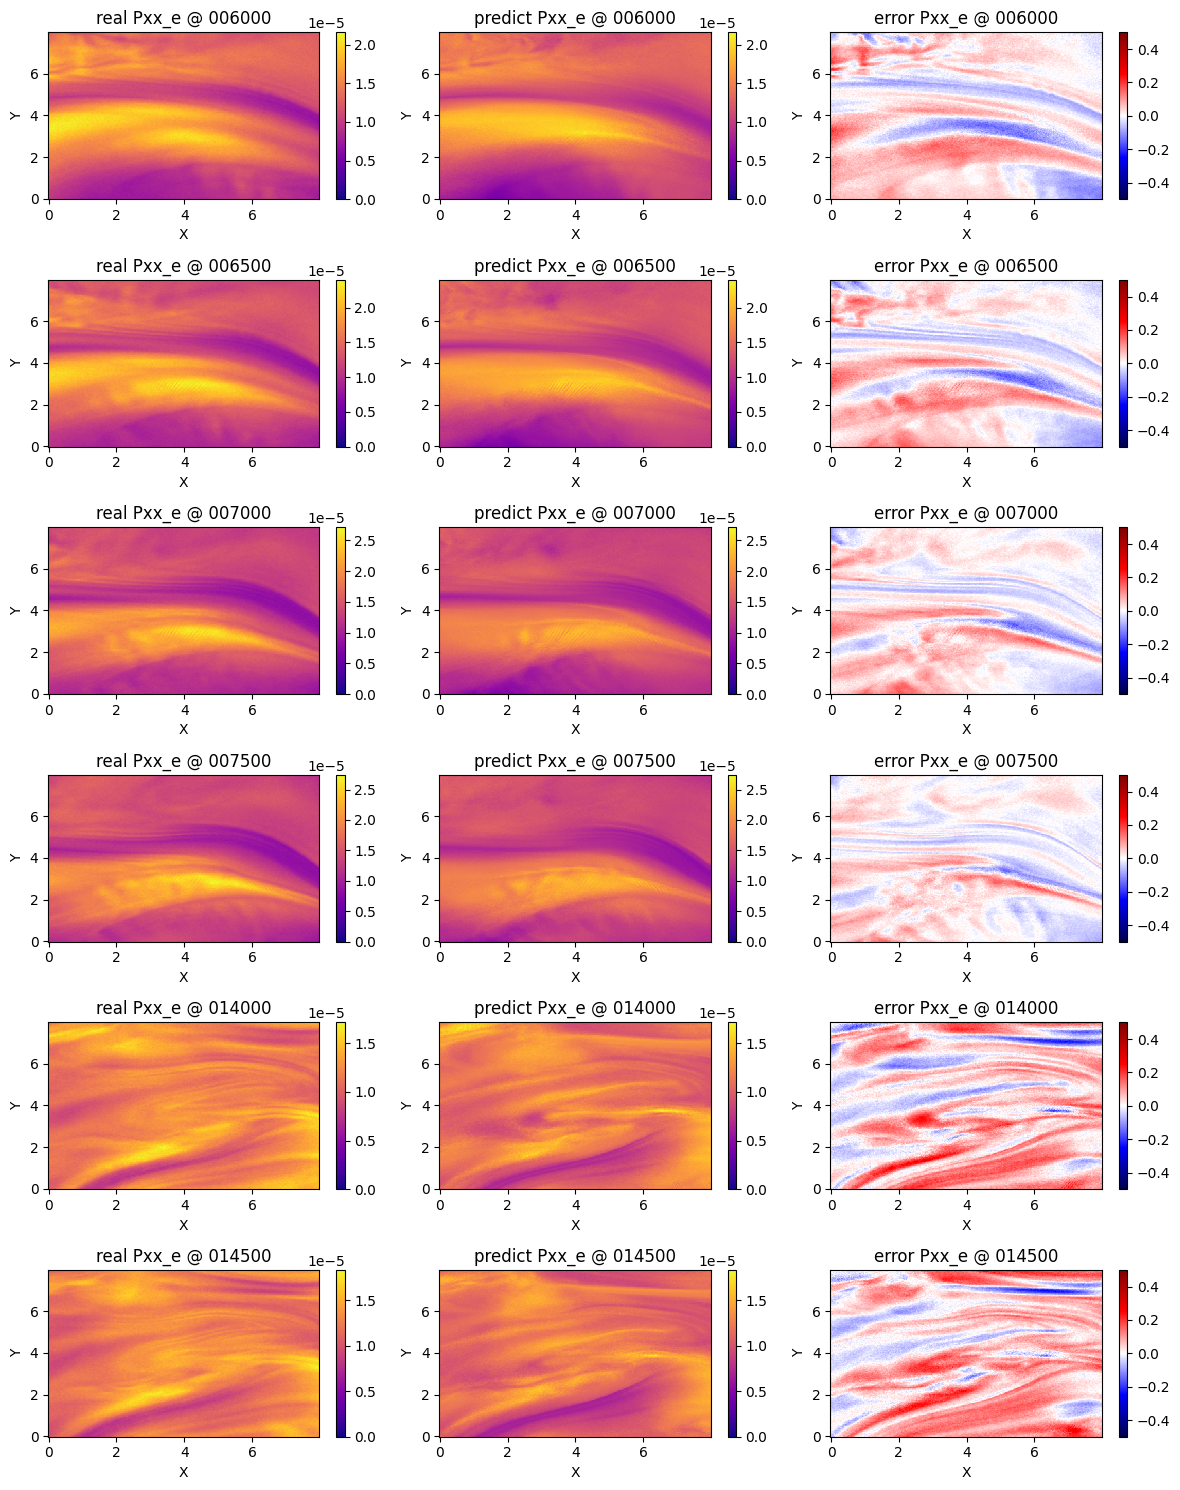

In [ ]:
torchscript_path = artifact_dir / 'haydn_mlp_torchscript.pt'

module_eval.network.eval()
example_input = torch.randn(32, model_cfg['feature_dims'][0])

try:
    scripted_model = torch.jit.script(module_eval.network.cpu())
except Exception as err:
    print('script failed, falling back to trace:', err)
    scripted_model = torch.jit.trace(module_eval.network.cpu(), example_input)

scripted_model.save(str(torchscript_path))
print('Saved TorchScript model:', torchscript_path)

## 11) Minimal inference utility using bundled normalization

invfunc = <function plot_pred_targets.<locals>.<lambda> at 0x7f30cf79bf60>


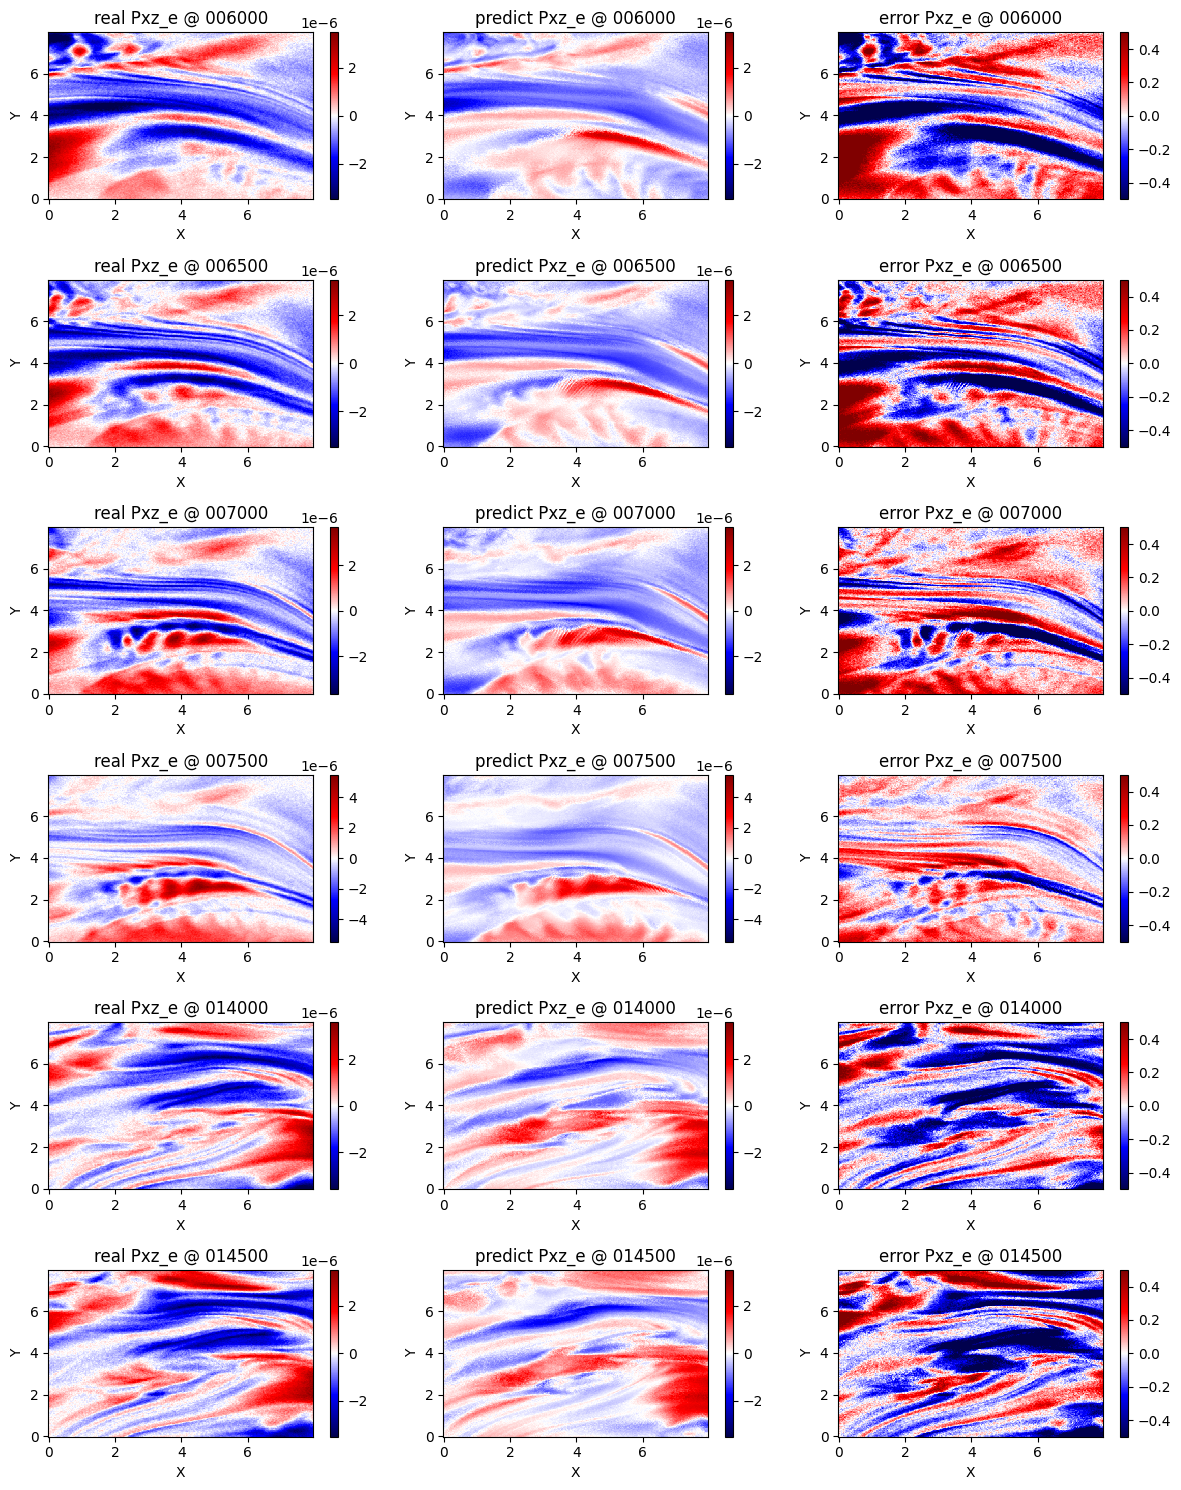

In [ ]:
def build_network_from_bundle(bundle):
    net = MLP(
        feature_dims=bundle['model_kwargs']['feature_dims'],
        activations=bundle['model_kwargs']['activations'],
    )
    net.load_state_dict(bundle['state_dict'])
    net.eval()
    return net


def predict_normalized(features_np, bundle, network=None):
    """Predict in normalized target space from raw feature rows.

    features_np shape: (n_samples, n_features)
    """
    if network is None:
        network = build_network_from_bundle(bundle)

    fmean = np.asarray(bundle['features_mean'])
    fstd = np.asarray(bundle['features_std'])
    x_norm = (features_np - fmean) / (fstd + 1e-12)

    with torch.no_grad():
        pred_norm = network(torch.tensor(x_norm, dtype=torch.float32)).cpu().numpy()
    return pred_norm

bundle_net = build_network_from_bundle(loaded_bundle)
sample_x = datamodule.test_dataset.features[:128].cpu().numpy()
sample_pred = predict_normalized(sample_x, loaded_bundle, network=bundle_net)
print('sample_pred shape:', sample_pred.shape)

## 12) Save a run manifest for reproducibility

This captures the exact config, checkpoints, and exported artifacts for the run.

In [ ]:
manifest = {
    'config_path': str(config_path),
    'train_csv': str(train_csv),
    'val_csv': str(val_csv),
    'test_csv': str(test_csv),
    'best_checkpoint': str(best_ckpt) if best_ckpt else None,
    'bundle_path': str(bundle_path),
    'torchscript_path': str(torchscript_path),
    'work_dir': str(work_dir),
}

manifest_path = artifact_dir / 'run_manifest.json'
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print('Saved manifest:', manifest_path)
print(json.dumps(manifest, indent=2))

In [ ]:
# Optional quick check: forward pass with TorchScript model
jit_model = torch.jit.load(str(torchscript_path), map_location='cpu')
with torch.no_grad():
    y_jit = jit_model(torch.tensor(sample_x[:16], dtype=torch.float32))
print('TorchScript output shape:', tuple(y_jit.shape))

Total loss 0.007214889244508741
Loss for channel 0: Pxx_e, loss = 0.013969622842585747
Loss for channel 1: Pyy_e, loss = 0.012994365790336188
Loss for channel 2: Pzz_e, loss = 0.01632534683264506
Loss for channel 3: Pxy_e, loss = 3.2632195693186777e-13
Loss for channel 4: Pxz_e, loss = 8.912262045497016e-13
Loss for channel 5: Pyz_e, loss = 2.678996038016104e-13


{'total_MSELoss': array(0.00721489),
 'Pxx_e_MSELoss': array(0.01396962),
 'Pyy_e_MSELoss': array(0.01299437),
 'Pzz_e_MSELoss': array(0.01632535),
 'Pxy_e_MSELoss': array(3.26321957e-13),
 'Pxz_e_MSELoss': array(8.91226205e-13),
 'Pyz_e_MSELoss': array(2.67899604e-13)}

## Appendix

The remaining cells can be used as scratch space for additional experiments.